In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *

In [ ]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_fixed_lag_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
mlp_param_grid = {
    'hidden_layer_sizes': [(128, 32), (64, 32, 32)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.001, 0.1],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [16, 32, 64],
    'max_iter': [1000],
}

xgb_param_grid = {
    # Number of trees
    'n_estimators': [100],

    # Tree complexity
    'max_depth': [3],          # deeper = more complex, shallower = less overfit
    'min_child_weight': [1],  # larger → more conservative splits

    # Learning rate (with estimator trade-off)
    'learning_rate': [0.1],

    # Regularization on splits
    'gamma': [0.1],          # min loss reduction to split

    # L1 & L2 penalties
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [1, 5],

    # Sampling (helps reduce overfit)
    'subsample': [0.8],
    'colsample_bytree': [1.0],
}

lightgbm_param_grid = {
    # Number of trees
    'n_estimators': [200],

    # Learning rate (pairs with n_estimators)
    'learning_rate': [0.01, 0.1],

    # Tree complexity
    'max_depth': [5],      # -1 = no limit
    'reg_alpha': [0.0, 0.1],
    'reg_lambda': [0.0, 0.1],

    # Sampling
    'subsample': [0.8],
    'colsample_bytree': [0.6],

    # Misc
    'verbose': [-1]
}


In [6]:
feature_df.fillna(-1, inplace=True)

In [7]:
run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: SklearnWrapper(LGBMClassifier, **params),
    model_param_grid=lightgbm_param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    uri=f'{REPO_PATH}/mlflow',
    key_columns=TRAINGING_CONFIG['key_columns'],
    model_name='LightGBMClassifier',
    save_model_path=TRAINGING_CONFIG['save_model_path']
)


Training LightGBMClassifier on home_goals with param grid: {'n_estimators': [200], 'learning_rate': [0.01, 0.1], 'max_depth': [5], 'reg_alpha': [0.0, 0.1], 'reg_lambda': [0.0, 0.1], 'subsample': [0.8], 'colsample_bytree': [0.6], 'verbose': [-1]}
Using range-based class conversion with range: (0, 5)
Training fold 1/5 with params: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 5, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.6, 'verbose': -1}
Training fold 2/5 with params: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 5, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.6, 'verbose': -1}
Training fold 3/5 with params: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 5, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 0.8, 'colsample_bytree': 0.6, 'verbose': -1}
Training fold 4/5 with params: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 5, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample

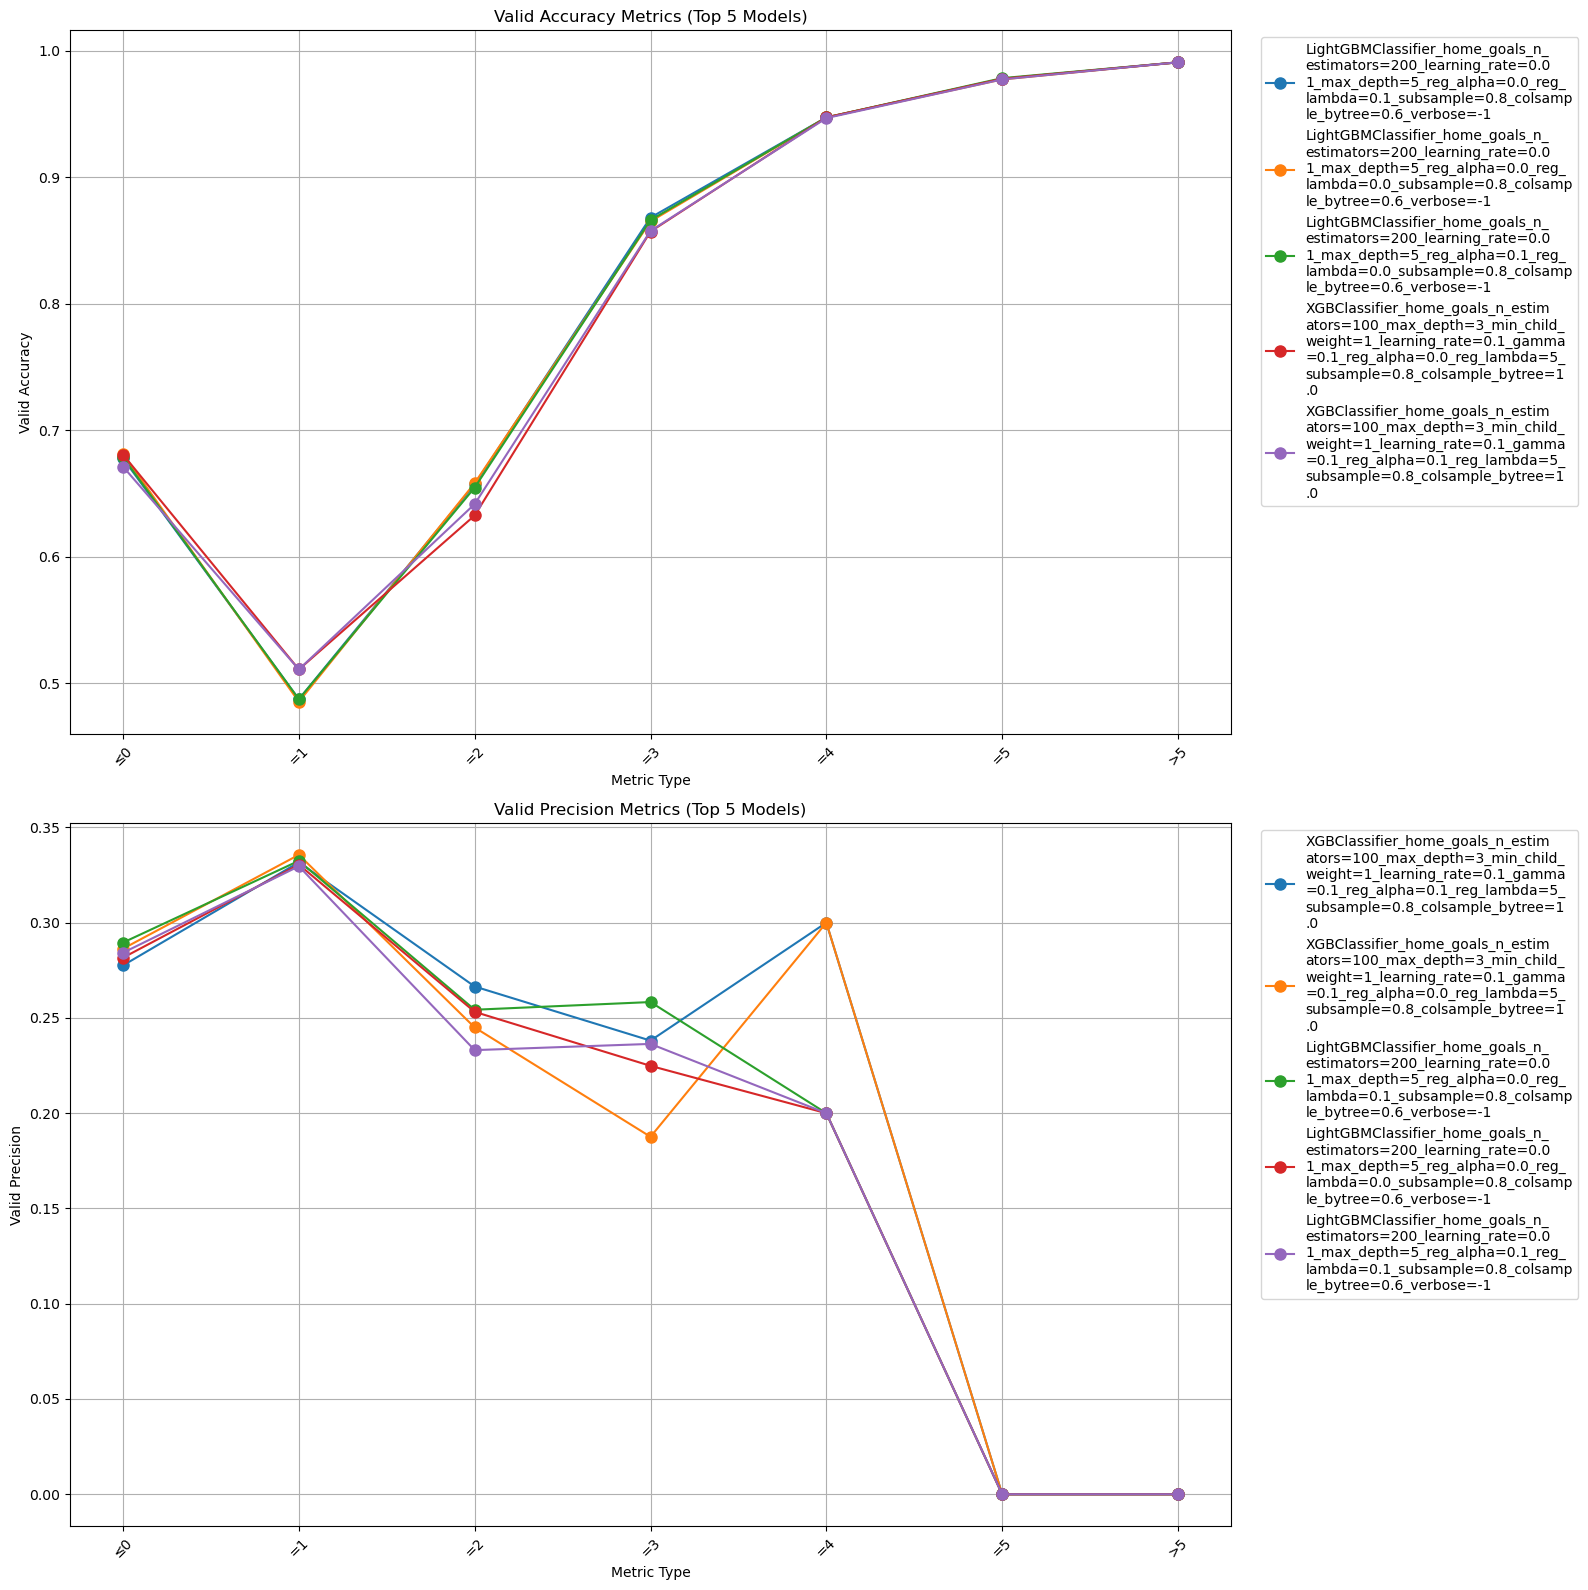

In [11]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

{'metrics.home_goals_train_gt_5_accuracy': 0.9998997493734336, 'metrics.home_goals_train_accuracy': 0.9716541353383459, 'metrics.home_goals_train_eq_1_accuracy': 0.9821386800334169, 'metrics.home_goals_train_eq_2_accuracy': 0.9890726817042605, 'metrics.home_goals_train_eq_4_accuracy': 0.9975522138680033, 'metrics.home_goals_train_eq_5_accuracy': 0.9993817878028404, 'metrics.home_goals_train_eq_3_accuracy': 0.9904594820384294, 'metrics.home_goals_train_lte_0_accuracy': 0.9848036758563075}
{'metrics.home_goals_valid_eq_5_accuracy': 0.9774436090225563, 'metrics.home_goals_valid_eq_1_accuracy': 0.5107769423558898, 'metrics.home_goals_valid_eq_3_accuracy': 0.8576441102756892, 'metrics.home_goals_valid_eq_2_accuracy': 0.6416040100250626, 'metrics.home_goals_valid_lte_0_accuracy': 0.6711779448621554, 'metrics.home_goals_valid_gt_5_accuracy': 0.9909774436090226, 'metrics.home_goals_valid_eq_4_accuracy': 0.9468671679197994, 'metrics.home_goals_valid_accuracy': 0.29824561403508765}
{'metrics.hom

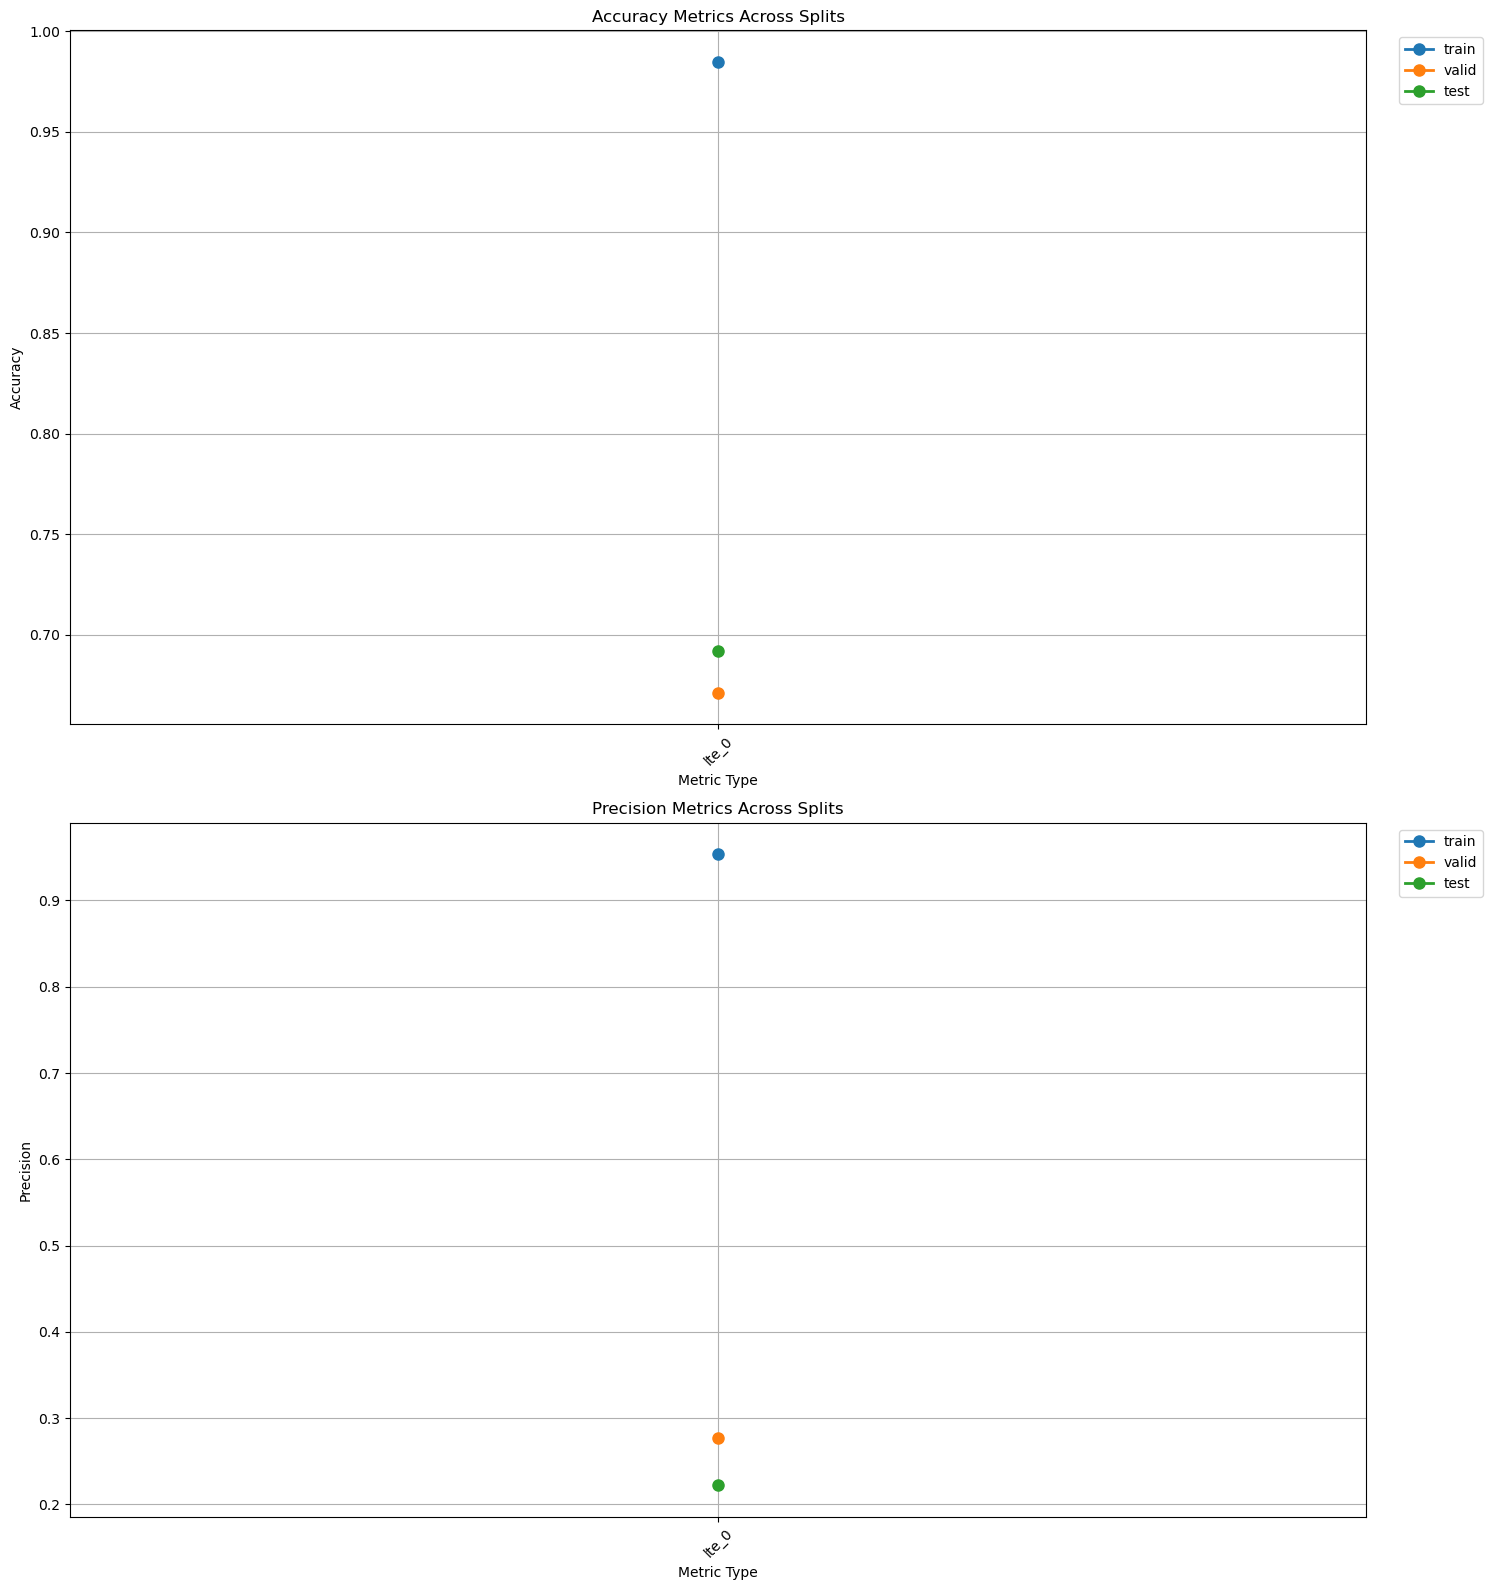

In [9]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="XGBClassifier_home_goals_n_estimators=100_max_depth=3_min_child_weight=1_learning_rate=0.1_gamma=0.1_reg_alpha=0.1_reg_lambda=5_subsample=0.8_colsample_bytree=1.0",
                         target_col="home_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

In [10]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="XGBClassifier",
                              model_param={'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'XGBClassifier' and params.n_estimators= '100' and params.max_depth= '5' and params.learning_rate= '0.01' and params.gamma= '0'
No runs found with model_name 'XGBClassifier' and params {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0}.
